# Curve Plotter

This notebook imports the helper functions from `plot_helper.py` to generate and display publication-grade comparison plots for self-tuning algorithms (e.g., `sfadamw`, `muon`, `ademamix`, etc.).
You can customize the styling parameters below and select which algorithms/workloads to plot.

In [1]:
import sys
from pathlib import Path

# Ensure the scratch directory is in python path
scratch_dir = Path('./').resolve()
if str(scratch_dir) not in sys.path:
    sys.path.append(str(scratch_dir))

import plot_helper
from plot_helper import ALGO_CONFIGS, configure_styling, plot_workload, find_workloads

## Customize Styling

You can override any Matplotlib RC parameters in the dictionary below. Call `configure_styling(custom_params)` to apply them.

In [2]:
# Default custom parameters (modify as desired)
custom_styles = {
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 14,             # Increased font size for better readability
    'axes.labelsize': 15,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 18
}

# Apply styling configurations
configure_styling(custom_styles)

## Select Algorithm & Generate Plots

Select which algorithm to plot (e.g., `'sfadamw'`, `'muon'`, `'ademamix'`, etc.) and the zoom type (`'log'` or `'percentile'`). Running this cell will process and display the plots inline in the notebook output console.

Found workloads for sfadamw: {'criteo1tb', 'librispeech_conformer', 'wmt', 'fastmri', 'librispeech_deepspeech', 'imagenet_vit', 'ogbg', 'finewebedu_lm', 'imagenet_resnet'}

Processing workload: criteo1tb


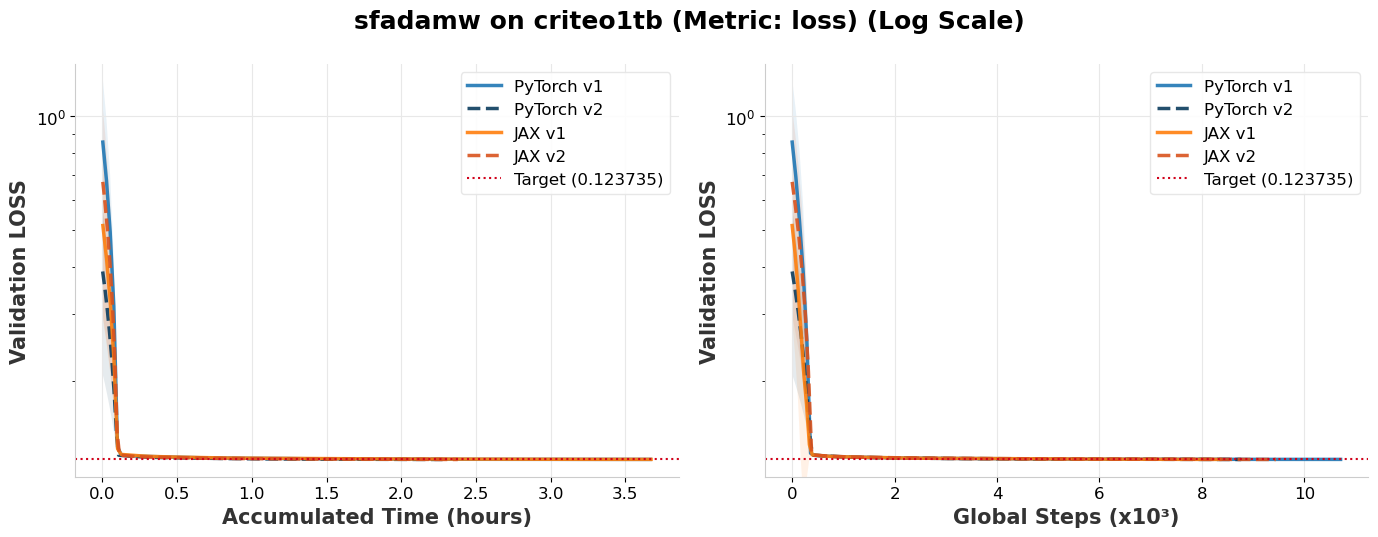

Saved PNG to /home/wyf/submissions_algorithms/logs/curve_plotting/sfadamw/criteo1tb_curves.png

Processing workload: librispeech_conformer


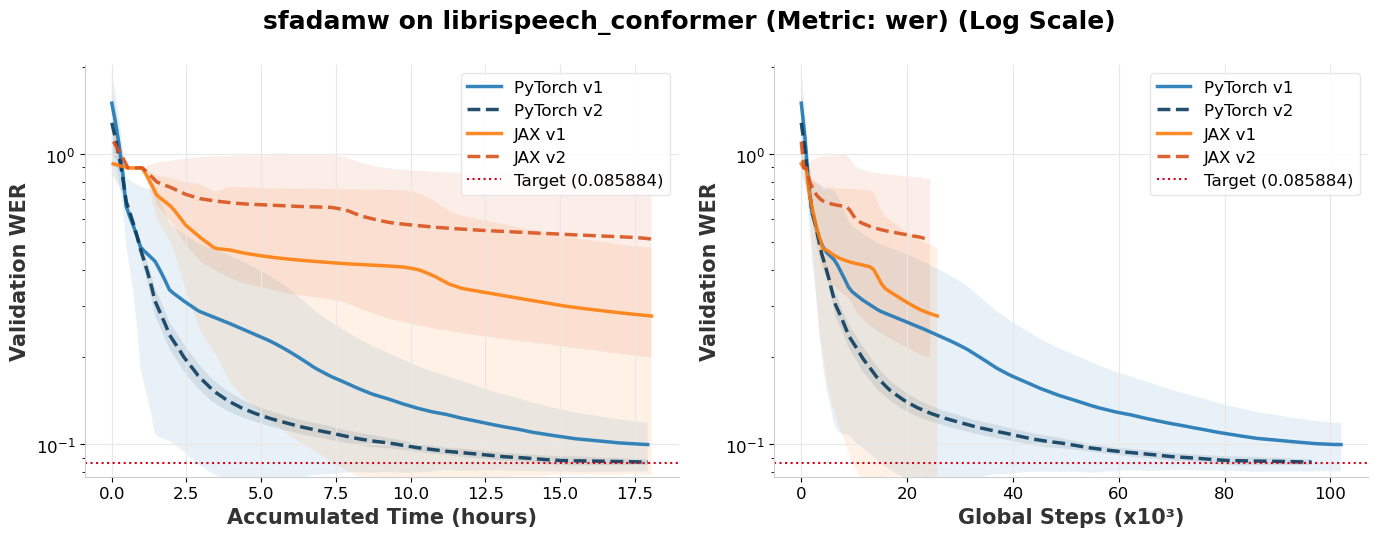

Saved PNG to /home/wyf/submissions_algorithms/logs/curve_plotting/sfadamw/librispeech_conformer_curves.png

Processing workload: wmt


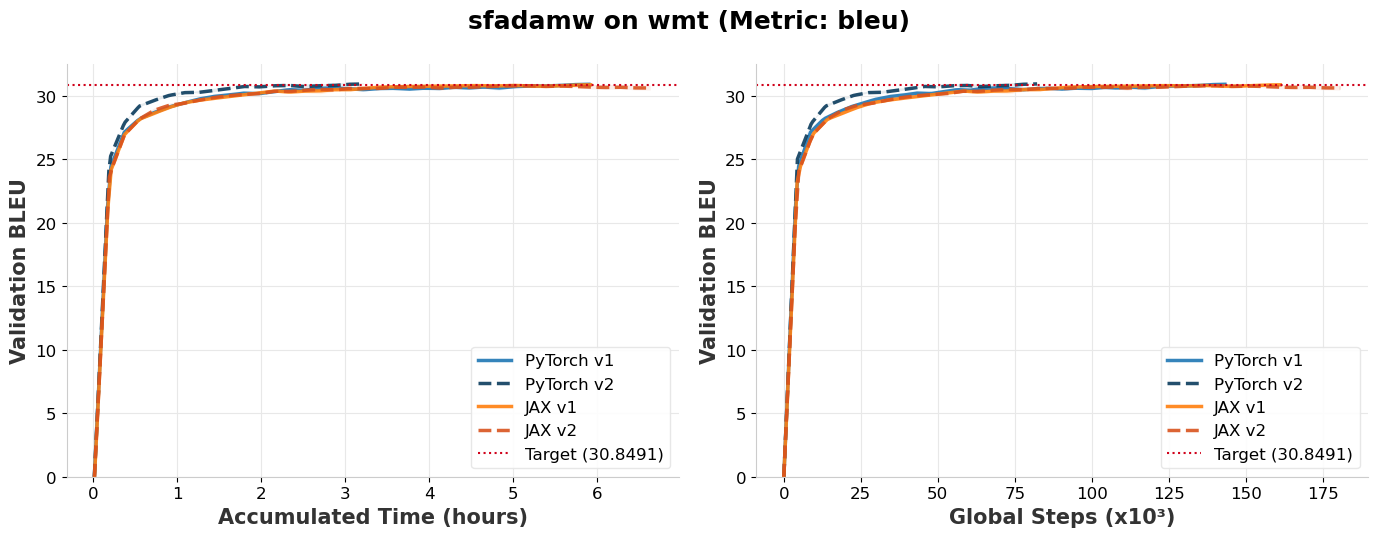

Saved PNG to /home/wyf/submissions_algorithms/logs/curve_plotting/sfadamw/wmt_curves.png

Processing workload: fastmri


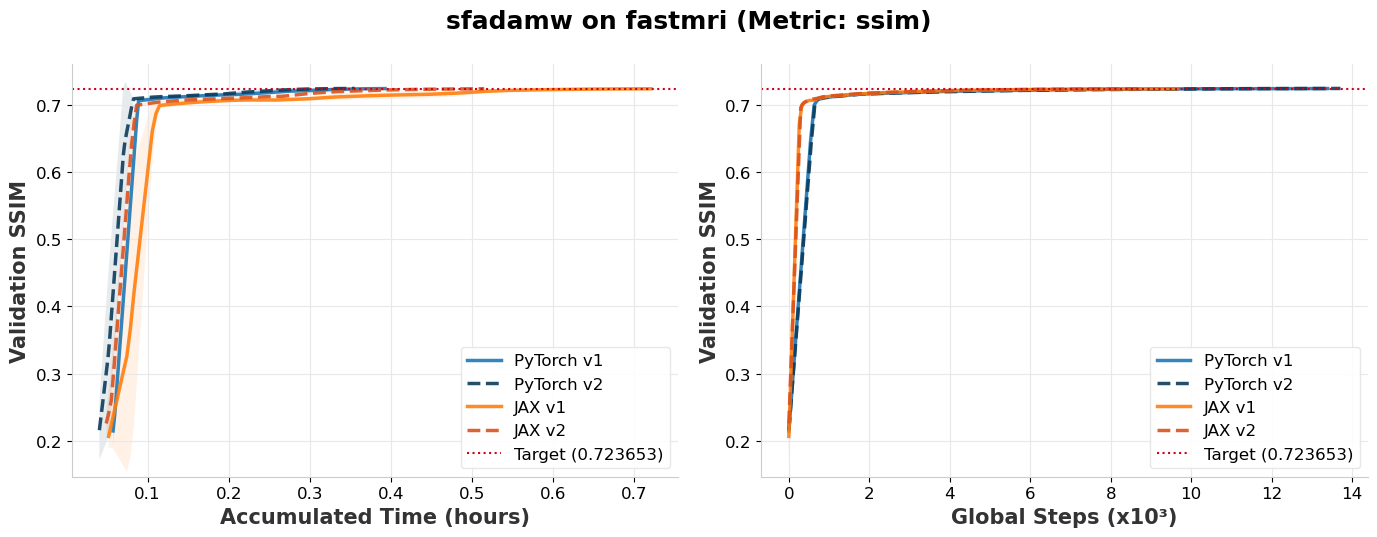

Saved PNG to /home/wyf/submissions_algorithms/logs/curve_plotting/sfadamw/fastmri_curves.png

Processing workload: librispeech_deepspeech


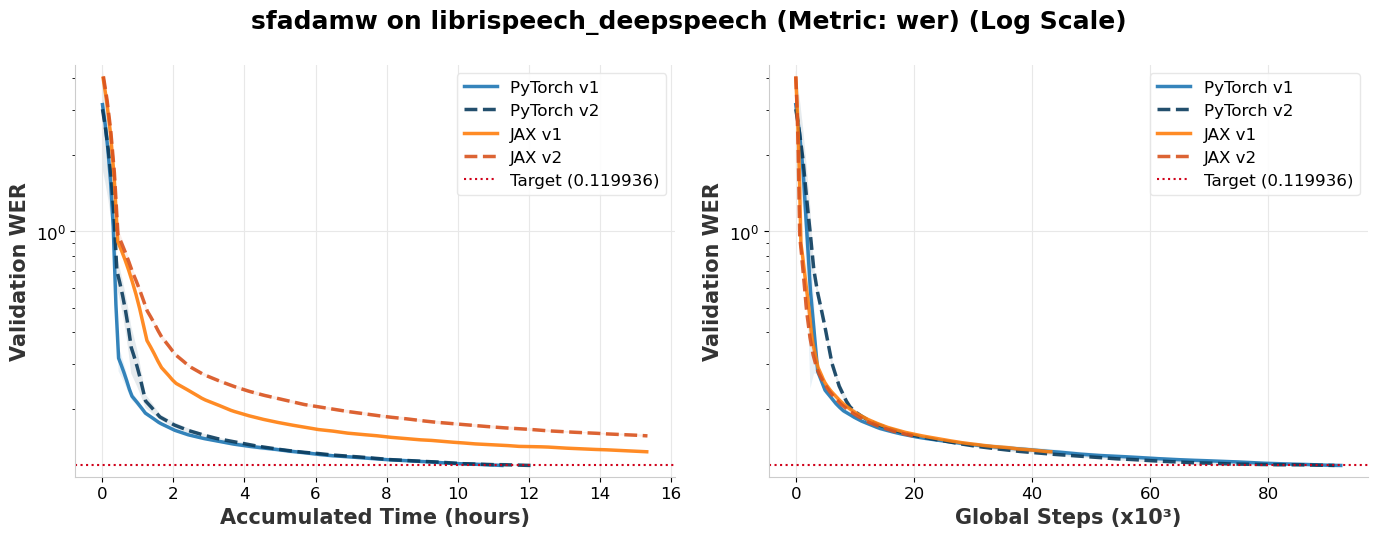

Saved PNG to /home/wyf/submissions_algorithms/logs/curve_plotting/sfadamw/librispeech_deepspeech_curves.png

Processing workload: imagenet_vit


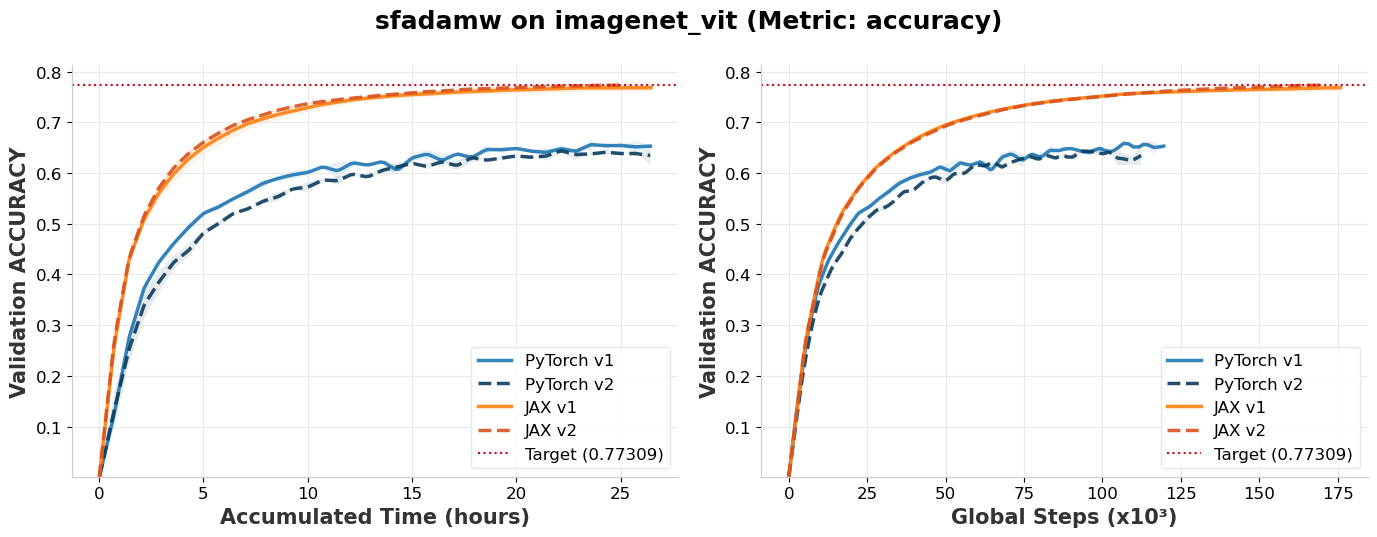

Saved PNG to /home/wyf/submissions_algorithms/logs/curve_plotting/sfadamw/imagenet_vit_curves.png

Processing workload: ogbg


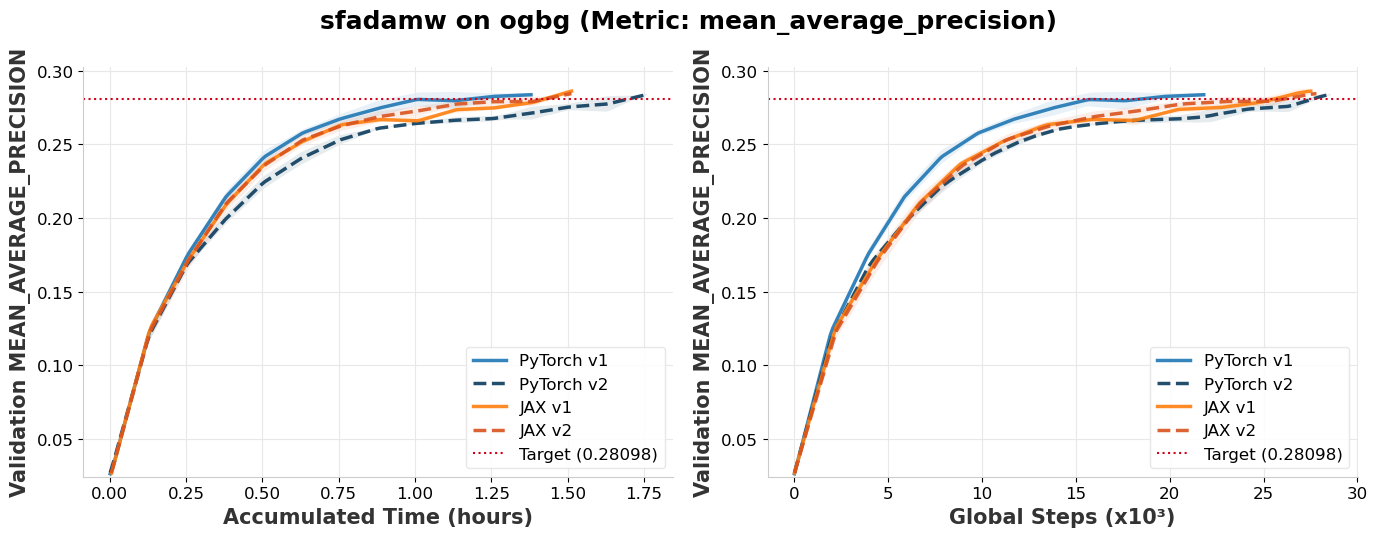

Saved PNG to /home/wyf/submissions_algorithms/logs/curve_plotting/sfadamw/ogbg_curves.png

Processing workload: finewebedu_lm


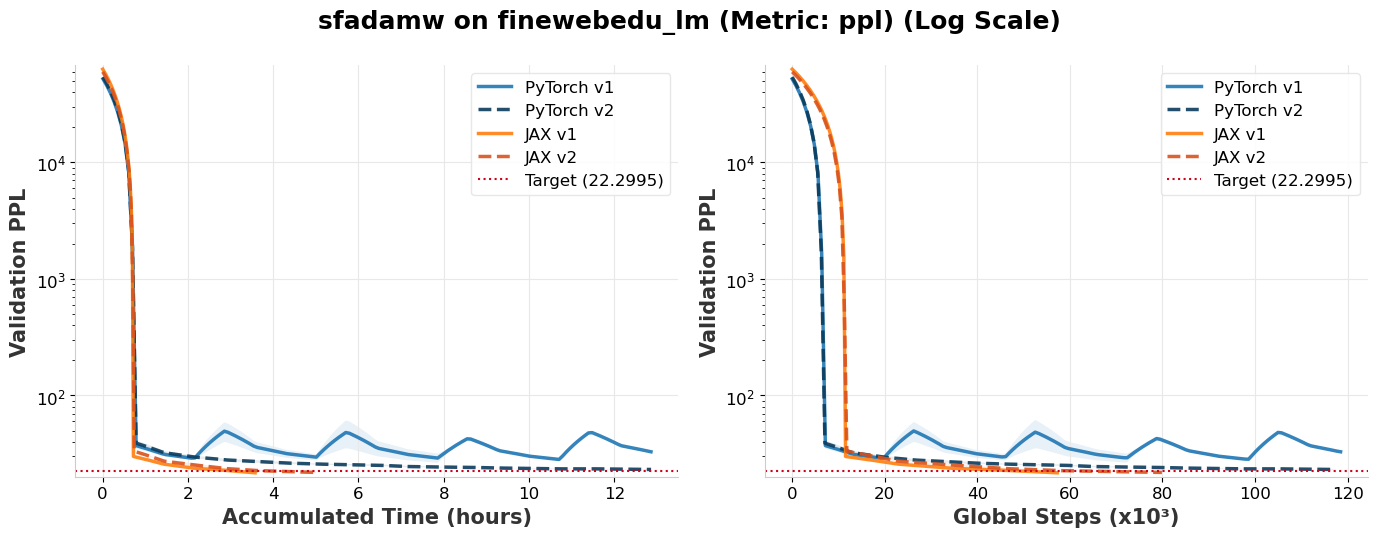

Saved PNG to /home/wyf/submissions_algorithms/logs/curve_plotting/sfadamw/finewebedu_lm_curves.png

Processing workload: imagenet_resnet


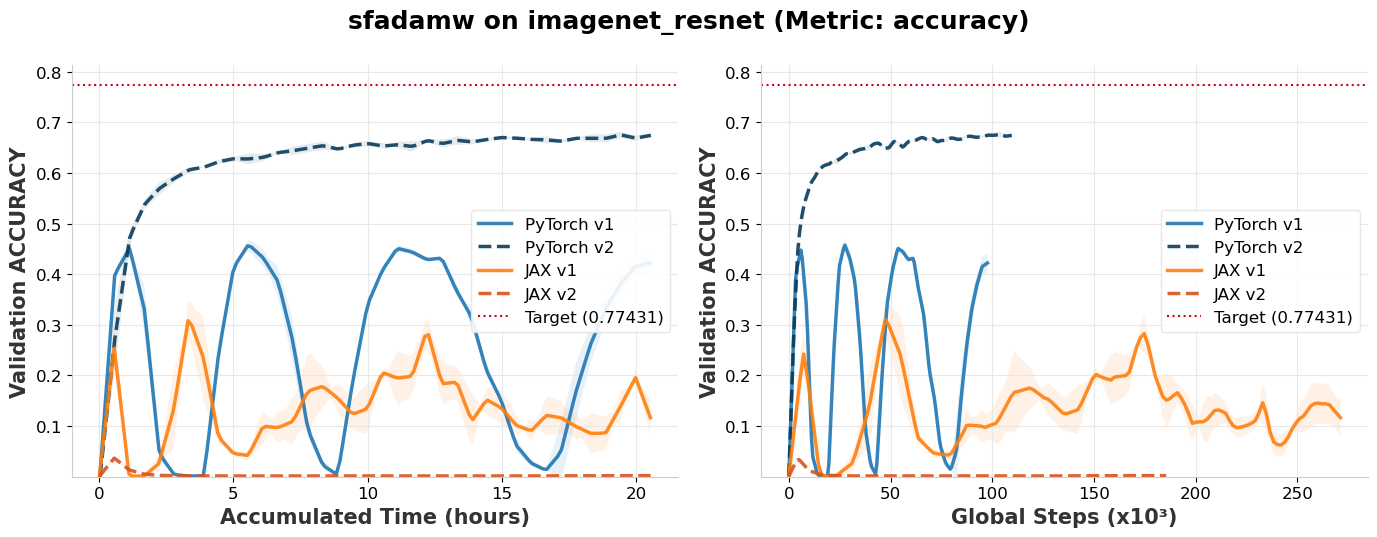

Saved PNG to /home/wyf/submissions_algorithms/logs/curve_plotting/sfadamw/imagenet_resnet_curves.png


In [3]:
# Parameters - feel free to change these
ALGO_NAME = 'sfadamw'    # Options: 'sfadamw', 'muon', 'ademamix', 'cautious_nadamw', 'lion', 'nadamw'
ZOOM_TYPE = 'log'        # Options: 'log', 'percentile'

# Configure directories
base_log_dir = Path('~/submissions_algorithms/logs/self_tuning').expanduser()
base_save_dir = Path('~/submissions_algorithms/logs/curve_plotting').expanduser()

if ALGO_NAME in ALGO_CONFIGS:
    config = ALGO_CONFIGS[ALGO_NAME]
    submissions = config['submissions']
    
    # Find all workloads for this algorithm
    workloads = find_workloads(base_log_dir, submissions)
    print(f"Found workloads for {ALGO_NAME}: {workloads}")
    
    for workload in workloads:
        print(f"\nProcessing workload: {workload}")
        plot_workload(
            workload=workload, 
            algo_name=ALGO_NAME, 
            submissions=submissions, 
            base_log_dir=base_log_dir, 
            base_save_dir=base_save_dir, 
            zoom=ZOOM_TYPE, 
            show_plot=True            # Show plots directly in notebook console
        )
else:
    print(f"Algorithm '{ALGO_NAME}' not found in ALGO_CONFIGS. Available: {list(ALGO_CONFIGS.keys())}")